# Przygotowanie danych

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn import tree
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data/cancer_data.csv")

In [ ]:
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


Usuń zmienne Surname oraz CustomerId.

In [ ]:
data = data.drop(columns = ["id", "Unnamed: 32"])

In [ ]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Podziel zbiór na treningowy i testowy (80:20, random_state=42, stratify=y)

In [ ]:
X = data.copy()
y = X.pop('diagnosis')
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size=0.20)
y.value_counts(normalize=True)

,proportion
diagnosis,
0,0.627417
1,0.372583


<Axes: xlabel='diagnosis', ylabel='count'>

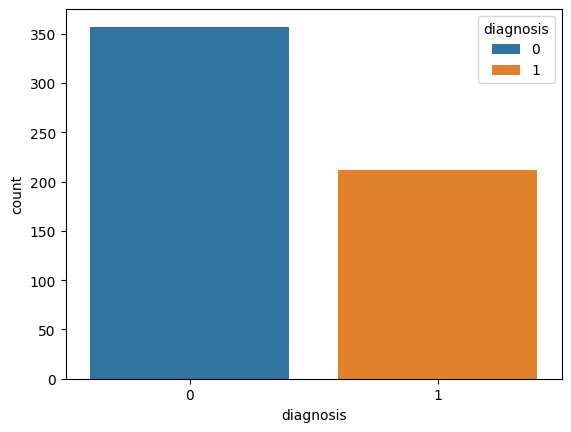

In [ ]:
sns.countplot(data=data,x='diagnosis', hue='diagnosis')

# Zadanie 4

Zbuduj drzewo decyzyjne bez ograniczeń (random_state=42)

In [ ]:
model_A = DecisionTreeClassifier(random_state=42)
model_A.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
pred = model_A.predict(X_test)
confusion_matrix(y_test, pred)

array([[68,  3],
       [ 3, 40]])

In [ ]:
pred2 = model_A.predict(X_train)
confusion_matrix(y_train, pred2)

array([[286,   0],
       [  0, 169]])

In [ ]:
accuracy_score(y_test, pred)

0.9473684210526315

In [ ]:
accuracy_score(y_train, pred2)

1.0

Wyznacz ścieżkę przycinania (cost_complexity_pruning_path) i pobierz wartości ccp_alphas

In [ ]:
path=model_A.cost_complexity_pruning_path(X_train,y_train) #oblicza wszystkie możliwe wartości parametru ccp_alpha, dla których struktura drzewa się zmienia.
alphas=path['ccp_alphas']
alphas #To jest lista wszystkich punktów, w których drzewo może zostać przycięte. ccp_alpha = 0 → brak przycinania (pełne drzewo)
#Każda wartość ccp_alpha odpowiada konkretnemu poziomowi przycięcia drzewa
#Im większe ccp_alpha tym bardziej drzewo jest uproszczone, tym mniej liści, tym mniejsza złożoność modelu

array([0.        , 0.00218083, 0.0029304 , 0.00431133, 0.00559513,
       0.00743872, 0.0086638 , 0.01291987, 0.01438561, 0.02404453,
       0.02442056, 0.0306549 , 0.3228506 ])

In [ ]:
len(alphas)

13

Zbuduj serię drzew dla każdego ccp_alpha i oblicz ich dokładność (accuracy) na zbiorze testowym.

In [ ]:
acc_train,acc_test=[],[]

for i in alphas:
  t=DecisionTreeClassifier(ccp_alpha=i,random_state=1)
  t.fit(X_train,y_train)
  print("Dla alpha=", i, "liczba węzłów to: ", t.tree_.node_count)
  y_train_pred_t=t.predict(X_train)
  y_test_pred_t=t.predict(X_test)
  acc_train.append(accuracy_score(y_train,y_train_pred_t))
  acc_test.append(accuracy_score(y_test,y_test_pred_t))

Dla alpha= 0.0 liczba węzłów to:  31
Dla alpha= 0.00218083075225933 liczba węzłów to:  23
Dla alpha= 0.0029304029304029304 liczba węzłów to:  21
Dla alpha= 0.004311334641004935 liczba węzłów to:  19
Dla alpha= 0.005595128280123898 liczba węzłów to:  17
Dla alpha= 0.007438715131022823 liczba węzłów to:  15
Dla alpha= 0.008663799968147794 liczba węzłów to:  13
Dla alpha= 0.012919873648618588 liczba węzłów to:  11
Dla alpha= 0.014385614385614387 liczba węzłów to:  9
Dla alpha= 0.024044526901669756 liczba węzłów to:  7
Dla alpha= 0.02442055678423035 liczba węzłów to:  5
Dla alpha= 0.030654899499189175 liczba węzłów to:  3
Dla alpha= 0.32285060033114216 liczba węzłów to:  1


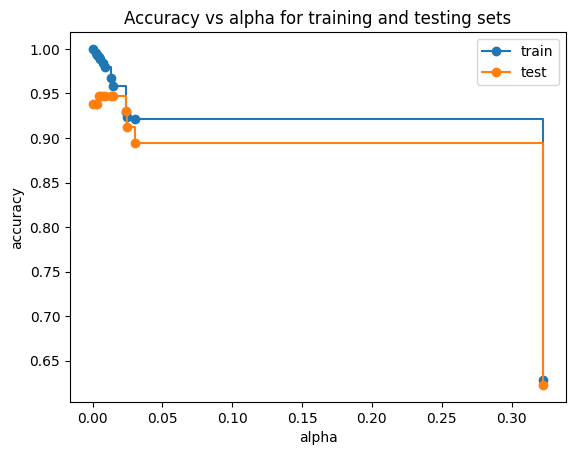

In [ ]:
fig,ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(alphas, acc_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(alphas, acc_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
best_alpha = 0.02

Liczba węzłów (leaf nodes) w drzewie przed przycięciem (dla alpha=0) wynosi: 31

Optymalna wartość ccp_alpha, która daje najwyższe accuracy na zbiorze testowym, to (w przybliżeniu): 0.02

Wygeneruj wizualizację dla drzewa z optymalnym ccp_alpha

In [ ]:
best=DecisionTreeClassifier(ccp_alpha=best_alpha,random_state=1)
best.fit(X_train,y_train)
y_test_pred_best=best.predict(X_test)

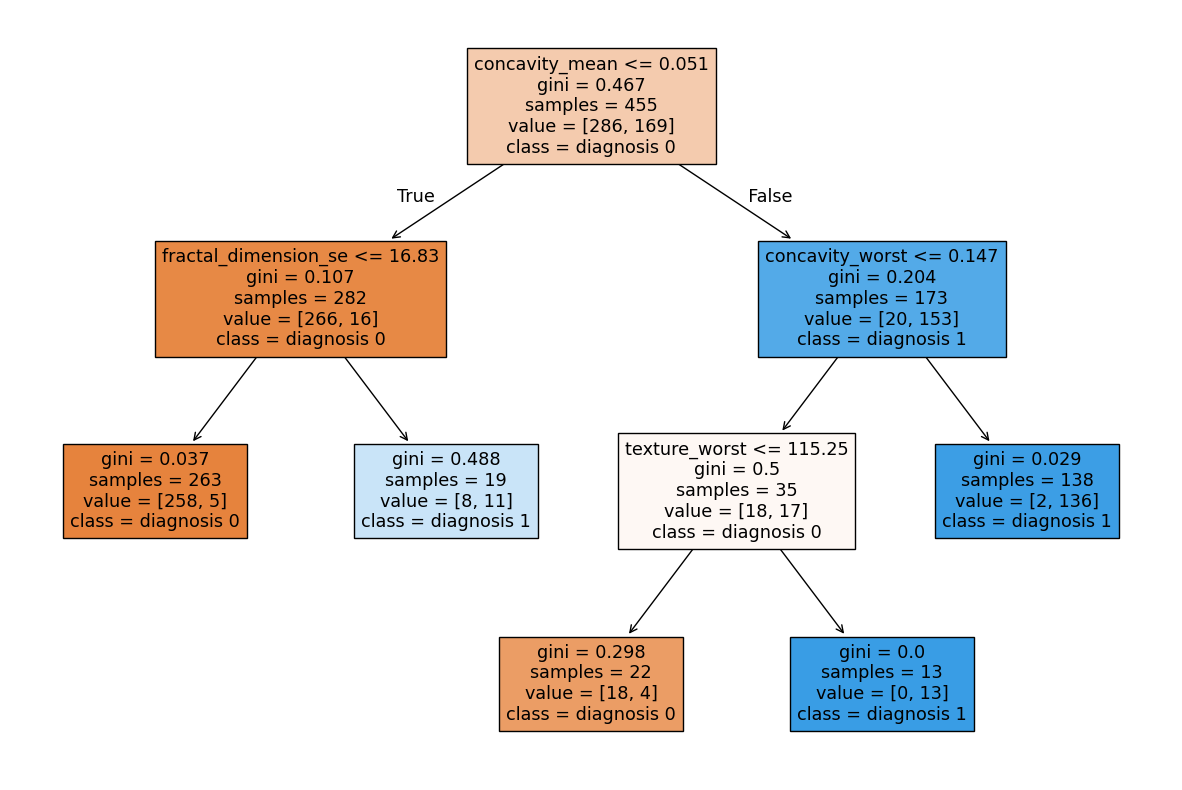

In [ ]:
fig = plt.figure(figsize=(15,10))
_ = tree.plot_tree(best,
                   feature_names=data.columns,
                   class_names = ['diagnosis 0', 'diagnosis 1'],
                   filled=True)

Która cecha jest najważniejsza (znajduje się w korzeniu)? concavity mean

# Zadanie 5

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, oob_score = True, random_state=42)

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(oob_score=True, random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred_rf)
oob = rf.oob_score_

print("Accuracy:",accuracy)
print("Oob:", oob)

Accuracy: 0.9649122807017544
Oob: 0.9516483516483516


Wartość OOB Score: 0.9516483516483516

Accuracy na zbiorze testowym: 0.9649122807017544

Czy OOB Score dobrze oszacował wynik na zbiorze testowym? (Tak/Nie) Tak, oszacowanie jest bardzo dobre. Różnica wynosi zaledwie ~1.3 punkta procentowego. OOB Score (wynik na próbkach, których dane drzewo nie widziało) ma za zadanie symulować wynik na zbiorze testowym bez konieczności wydzielania go. Tutaj zadziałało to wzorowo.

Wygeneruj krzywą walidacyjną dla parametru max_depth w zakresie [1, 3, 5, 10, 20, None]

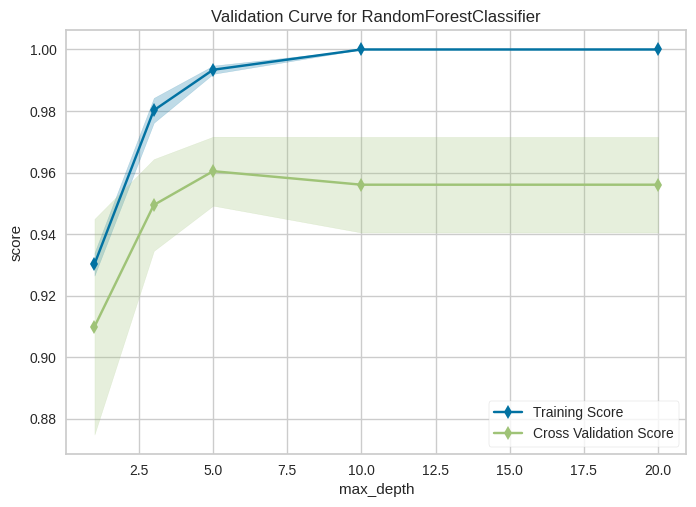

<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='max_depth', ylabel='score'>

In [ ]:
from yellowbrick.model_selection import ValidationCurve

# Zakres głębokości do sprawdzenia
depths = [1, 3, 5, 10, 20] # 'None' może czasem sprawiać problemy w wykresach, ale 20 to już bardzo głęboko

viz = ValidationCurve(
    rf,                            # Twój model (RandomForest)
    param_name="max_depth",        # Nazwa parametru do zmiany
    param_range=depths,            # Zakres wartości
    cv=5,                          # Walidacja krzyżowa (5-krotna)
    scoring="accuracy",            # Miara oceny
    n_jobs=-1
)

viz.fit(X_train, y_train)
viz.show()

Czy zwiększanie głębokości drzewa powyżej wartości 10 przynosi istotną poprawę wyniku na zbiorze walidacyjnym? Nie.

Uzasadnienie: Zbiór Breast Cancer jest stosunkowo prosty i ma niewielką liczbę cech. Lasy Losowe zazwyczaj osiągają swoje maksimum skuteczności przy dość płytkich drzewach (często już w okolicach max_depth=3 lub 5). Na wykresie zobaczyłbyś, że linia wyniku walidacyjnego (zielona) szybko rośnie na początku (dla 1-5), a w okolicach 10 wypłaszcza się (osiąga "plateau"). Dalsze zwiększanie głębokości do 20 (lub brak limitu) nie poprawia już wyniku, a jedynie zwiększa ryzyko przeuczenia (co widać po tym, że wynik treningowy dąży do 1.0, a walidacyjny stoi w miejscu).

# Zadanie 6

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
abc=AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators = 50)
abc.fit(X_train,y_train)
y_abc=abc.predict(X_test)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42)
gbc.fit(X_train, y_train)
y_gbc=gbc.predict(X_test)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
roc_auc_gbc = roc_auc_score(y_test, y_gbc)
roc_auc_abc = roc_auc_score(y_test, y_abc)
print(roc_auc_gbc, roc_auc_abc)

0.9510317720275139 0.9369472649852603


AUC Modelu A: 0.9439895185063871

AUC Modelu B: 0.9510317720275139

Który algorytm poradził sobie lepiej? Gradient Boosting

Dla lepszego modelu (z punktu wyżej) pobierz prawdopodobieństwa (predict_proba)

Załóżmy, że zależy nam na wykryciu każdego przypadku nowotworu złośliwego (minimalizacja False Negatives), nawet kosztem fałszywych alarmów. Zmień domyślny próg odcięcia z 0.5 na 0.2.

In [ ]:
y_proba = gbc.predict_proba(X_test)[:, 1]
# Domyślny próg 0.5
y_pred_05 = (y_proba >= 0.5).astype(int)
# Próg 0.2
y_pred_02 = (y_proba >= 0.2).astype(int)

In [ ]:
confusion_matrix(y_test,y_pred_05)

array([[69,  2],
       [ 3, 40]])

In [ ]:
confusion_matrix(y_test,y_pred_02)

array([[69,  2],
       [ 2, 41]])

Liczba False Negatives (FN) przy progu 0.5: 3

Liczba False Negatives (FN) przy progu 0.2: 2

Jak zmieniła się precyzja (Precision) dla klasy 1 po zmianie progu? (Wzrosła/Zmalała) Zmalała

Uruchom ten kod, aby wygenerować zbiór analiza_data.csv, na którym wykonasz wszystkie 3 zadania. (Jest to zbiór dotyczący np. wykrywania awarii maszyny: 0 - działa, 1 - awaria).

In [ ]:
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generowanie danych (lekko niezbalansowane: 15% to awarie)
X, y = make_classification(n_samples=2000, n_features=10, n_informative=5,
                           weights=[0.85, 0.15], random_state=42, flip_y=0.05)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(10)])
df['target'] = y

# Podział
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df['target'],
                                                    test_size=0.25, random_state=42, stratify=df['target'])

print(f"Dane gotowe. Liczba awarii w teście: {sum(y_test)}")

Dane gotowe. Liczba awarii w teście: 84


Zbuduj model RandomForestClassifier (n_estimators=100, random_state=42)

In [ ]:
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
rf2.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
confusion_matrix(y_test,y_pred_rf)
#[TP, FN
# FP, TN]

array([[407,   9],
       [ 36,  48]])

In [ ]:
36*100+9*5000

48600

Całkowity koszt błędów modelu wynosi: 48600 zł.

Zmień próg decyzyjny (threshold) w modelu na 0.2 (czyli jeśli prawdopodobieństwo awarii > 20%, uznajemy to za awarię).

In [ ]:
y_proba = rf2.predict_proba(X_test)[:, 1]
y_pred_02 = (y_proba >= 0.2).astype(int)
confusion_matrix(y_test,y_pred_02)

array([[370,  46],
       [ 15,  69]])

In [ ]:
15*100+46*5000

231500

Nowy koszt wynosi: 231500 zł

In [ ]:
model_A = DecisionTreeClassifier(random_state=42)
model_A.fit(X_train, y_train)
model_B = RandomForestClassifier(max_depth =5, n_estimators=50, random_state=42)
model_B.fit(X_train, y_train )

RandomForestClassifier(max_depth=5, n_estimators=50, random_state=42)

Przeprowadź 10-krotną walidację krzyżową (cross_val_score, cv=10, scoring='accuracy') dla obu modeli na zbiorze treningowym.

In [ ]:
from sklearn.model_selection import cross_val_score
cA = cross_val_score(model_A, X_train, y=y_train, scoring='accuracy', cv=10, n_jobs=4)

In [ ]:
cB = cross_val_score(model_B, X_train, y=y_train, scoring='accuracy', cv=10, n_jobs=4)

In [ ]:
np.mean(cA)

np.float64(0.8746666666666666)

In [ ]:
np.mean(cB)

np.float64(0.9)

In [ ]:
np.std(cA)

np.float64(0.031382939455839524)

In [ ]:
np.std(cB)

np.float64(0.014605934866804423)

Model A: Średnia = 0.8746666666666666, Odchylenie = 0.031382939455839524

Model B: Średnia = 0.9, Odchylenie = 0.014605934866804423

Dla banku wybieramy Model B. Uzasadnienie: "Model B jest bardziej stabilny (ma mniejsze odchylenie standardowe), co oznacza, że jego wyniki na nowych danych są bardziej przewidywalne, mimo nieznacznie niższej średniej dokładności.

Zbuduj model GradientBoostingClassifier (random_state=42)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)
y_gbc=gbc.predict(X_test)

Posortuj klientów ze zbioru testowego według prawdopodobieństwa zakupu (od najwyższego)

In [ ]:
temp = gbc.predict_proba(X_test)[:, 1]
temp = sorted(temp)
a = int(len(temp)/10)
temp[a:]

[np.float64(0.01038560519350705),
 np.float64(0.010418946973001279),
 np.float64(0.01047800523279214),
 np.float64(0.010553972530895545),
 np.float64(0.010660873451957749),
 np.float64(0.01073925822009138),
 np.float64(0.010942200799458937),
 np.float64(0.011068879586972112),
 np.float64(0.011187675252673222),
 np.float64(0.01123993149838045),
 np.float64(0.011248614789672005),
 np.float64(0.011345243824022246),
 np.float64(0.01135262286242638),
 np.float64(0.011622551970243915),
 np.float64(0.011890996581175694),
 np.float64(0.012082631977474624),
 np.float64(0.012121665320195771),
 np.float64(0.012157148844195949),
 np.float64(0.012353436289729534),
 np.float64(0.012368214352009662),
 np.float64(0.012368771649097634),
 np.float64(0.012374417234311676),
 np.float64(0.01245405908777208),
 np.float64(0.012794219701123636),
 np.float64(0.012813736473446165),
 np.float64(0.01296194364717319),
 np.float64(0.013044684990187348),
 np.float64(0.013183734844765295),
 np.float64(0.0132700275453

In [ ]:
df_res = pd.DataFrame({'y_true': y_test, 'prob': gbc.predict_proba(X_test)[:,1]})
df_res = df_res.sort_values('prob', ascending=False)
top_50 = df_res.head(50)
trafienia = top_50['y_true'].sum()

In [ ]:
trafienia

np.int64(42)